# <span style="color: orange;"><b>VideoFlexTok</b></span>: Flexible-Length Coarse-to-Fine Video Tokenization

[`Website`](https://videoflextok.epfl.ch) | [`arXiv`]() | [`GitHub`]()

Official implementation for: <br>
[**VideoFlexTok: Flexible-Length Coarse-to-Fine Video Tokenization**](), arXiv 2026 <br>
*[Andrei Atanov](https://andrewatanov.github.io)\*, [Jesse Allardice](https://github.com/JesseAllardice)\*, [Roman Bachmann](https://roman-bachmann.github.io/), [Oğuzhan Fatih Kar](https://ofkar.github.io/), [R Devon Hjelm](https://rdevon.github.io/), [David Griffiths](https://www.dgriffiths.uk/), [Peter Fu](https://scholar.google.com/citations?user=zAgqOn8AAAAJ&hl=en&oi=ao), [Afshin Dehghan](https://scholar.google.com/citations?user=wcX-UW4AAAAJ), [Amir Zamir](https://vilab.epfl.ch/zamir/)*


Please make sure to follow the installation instructions outlined in the official repository. We recommend running this notebook on A100s or H100s and to perform inference in `bfloat16`.

----------------

# Setup and utils

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Switch path to root of project
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import torch
from videoflextok.utils.misc import get_bf16_context, detect_bf16_support

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

# Global no_grad
torch.set_grad_enabled(False)

enable_bf16 = detect_bf16_support()
print('BF16 enabled:', enable_bf16)

device = torch.device(f"cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)

BF16 enabled: True
Device: cuda


In [3]:
from videoflextok.utils.demo import denormalize
import imageio.v3 as iio
import tempfile
from IPython.display import Video, display

def show_frame_row(video_cthw: torch.Tensor, step: int = 1, figsize=(15, 4), pad: int = 0):
    """
    Show a row of frames using matplotlib.
    - step: take every 'step' frame (e.g., step=2 → every second frame)
    - pad: pixels of vertical padding between frames
    """
    
    frames = denormalize(video_cthw)
    frames = frames.permute(1, 2, 3, 0).contiguous().numpy()  # [T,H,W,C] in [0,1]
    frames = frames[::step]

    if pad > 0:
        H, W, C = frames.shape[1:]
        pad_block = np.ones((H, pad, C), dtype=np.uint8)
        strip = np.concatenate(
            [np.concatenate((f, pad_block), axis=1) for f in frames[:-1]] + [frames[-1]],
            axis=1
        )
    else:
        strip = np.concatenate(list(frames), axis=1)

    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(strip)
    plt.show()


def _add_bottom_pad(frames: np.ndarray, pad_px: int = 40, color=(0, 0, 0)) -> np.ndarray:
    """frames: [T,H,W,3] uint8. Returns frames with extra padding at the bottom.
    - pad_px: pixels to add; 0 disables
    - color: RGB tuple for pad color
    """
    if pad_px <= 0:
        return frames
    assert frames.ndim == 4 and frames.shape[-1] == 3, "expected [T,H,W,3]"
    T, H, W, C = frames.shape
    pad = np.zeros((T, pad_px, W, C), dtype=np.uint8)
    if isinstance(color, (tuple, list, np.ndarray)):
        color_arr = np.array(color, dtype=np.uint8).reshape(1, 1, 1, 3)
        pad[:] = color_arr
    elif isinstance(color, (int, np.integer)):
        pad[:] = np.uint8(color)
    else:
        # fallback to black
        pad[:] = 0
    return np.concatenate([frames, pad], axis=1)


def show_videos_row_video(videos, fps: int = 8, gap: int = 2, bottom_pad_px: int = 0):
    """
    Display multiple 256x256 videos stacked horizontally in a single MP4.
    
    Args:
      videos: list of [C,T,H,W] or [1,C,T,H,W] tensors
      fps: frames per second
      gap: horizontal gap in pixels between videos
      bottom_pad_px: pixels of bottom padding to avoid player controls overlay
    """
    # Convert to uint8 frames
    frames_list = []
    for v in videos:
        if v.ndim == 5:
            v = v[0]  # [1,C,T,H,W] -> [C,T,H,W]
        frames = denormalize(v).permute(1, 2, 3, 0).contiguous().numpy().clip(0, 1)  # [T,H,W,3] float32 [0,1]
        frames = (frames * 255).round().astype(np.uint8)  # Convert to uint8
        frames_list.append(frames)
    
    # Stack horizontally with gaps
    T = frames_list[0].shape[0]
    H = frames_list[0].shape[1]
    composed = []
    for t in range(T):
        row = []
        for i, f in enumerate(frames_list):
            row.append(f[t])
            if gap > 0 and i < len(frames_list) - 1:
                row.append(np.zeros((H, gap, 3), dtype=np.uint8))
        composed.append(np.concatenate(row, axis=1))
    composed = np.stack(composed, axis=0)
    
    # Add bottom padding for player controls
    composed = _add_bottom_pad(composed, pad_px=bottom_pad_px, color=(255, 255, 255))
    
    # Write and display
    with tempfile.NamedTemporaryFile(suffix='.mp4', delete=False) as tmp:
        tmp_path = tmp.name
    try:
        iio.imwrite(tmp_path, composed, fps=fps, plugin='FFMPEG', codec='libx264', pixelformat='yuv420p')
        with open(tmp_path, 'rb') as f:
            display(Video(data=f.read(), embed=True, mimetype='video/mp4'))
    finally:
        try:
            os.remove(tmp_path)
        except OSError:
            pass


/opt/conda/lib/python3.12/site-packages/torchvision/transforms/_functional_video.py:6: UserWarning: The 'torchvision.transforms._functional_video' module is deprecated since 0.12 and will be removed in the future. Please use the 'torchvision.transforms.functional' module instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/transforms/_transforms_video.py:22: UserWarning: The 'torchvision.transforms._transforms_video' module is deprecated since 0.12 and will be removed in the future. Please use the 'torchvision.transforms' module instead.
  warnings.warn(


# Loading model

In [ ]:
from videoflextok.wrappers import VideoFlexTokFromHub

model = VideoFlexTokFromHub.from_pretrained("EPFL-VILAB/videoflextok_d18_d28")
model.to(device).eval();

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Outdated diffusers. Install `pip install --upgrade git+https://github.com/huggingface/diffusers@a1d55e1`
Loading weights from local directory


# Load video sample

In [5]:
from videoflextok.utils.demo import read_mp4

video_path = "data/video_examples/porsche.mp4"
video_tensor = read_mp4(video_path, fps=8)  # (C, T, H, W)
print(f"Number of frames: {video_tensor.shape[1]}")

Number of frames: 33


In [6]:
show_videos_row_video([video_tensor])

# Variable-length Reconstruction

In [7]:
with get_bf16_context(enable_bf16):
    token_ids = model.tokenize(video_tensor[None].to(device))  # List of (1, t, 256) tokens, where T = 1 + 4 * (t - 1) -> t = (T + 3) // 4
    print('Token ids shape:', [t.shape for t in token_ids])

/root/ml-videoflextok/videoflextok/model/utils/posembs.py:133: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  posembs = posembs[slices]


Token ids shape: [torch.Size([1, 9, 256])]


In [8]:
# flow sampling parameters
decoder_generation_kwargs = dict(
    timesteps=40, # Number of denoising steps
    guidance_scale=25, # Classifier-free guidance scale
    perform_norm_guidance=True, # APG, see https://arxiv.org/abs/2410.02416,
    generator=torch.Generator(device).manual_seed(42), # for reproducibility
    eta=0.,
    momentum=0.,
    norm_threshold=0.6,
    verbose=False, # Enable to show denoising progress bar with tqdm
)

In [9]:
num_keep_tokens_list = [2**i for i in range(9)] # 1, 2, 4, 8, ..., 256

with get_bf16_context(enable_bf16):
    reconstructed_videos = model.detokenize(
        [token_ids[0] for _ in range(len(num_keep_tokens_list))],
        num_keep_tokens_list=num_keep_tokens_list,
        **decoder_generation_kwargs
    ) # List of videos of shape (1, C, T, H, W) in [-1, 1]
    reconstructed_videos = [r.cpu().float() for r in reconstructed_videos]  # Move to CPU for visualization

/root/ml-videoflextok/videoflextok/model/utils/posembs.py:133: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  posembs = posembs[slices]


/root/ml-videoflextok/videoflextok/model/utils/posembs.py:133: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  posembs = posembs[slices]
/root/ml-videoflextok/videoflextok/model/utils/posembs.py:133: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  posembs = posembs[slices]


In [10]:
show_videos_row_video(reconstructed_videos, bottom_pad_px=128, fps=8)

# Frame-conditional decoding ("editing probing")

This section provide a code example replicating the probing experiment from the paper. Specifically, we decode the video using the first few tokens of the original video, while conditioning on the edited first frame. 

**Note:** this is not an intended use case as the model is not trained for this scenario. We provide this code example for the sake of curiosity into the model's behavior, but <mark>we do not expect the model to perform "well" in this setting.</mark>

## Load a source video for editing

In [11]:
video_path = "./data/frame_edits/orig_clip.mp4"
video_tensor = read_mp4(video_path, fps=8)  # (C, T, H, W)
show_videos_row_video([video_tensor])

In [12]:
# tokenize the original video
with get_bf16_context(enable_bf16):
    token_ids = model.tokenize(video_tensor[None].to(device))  # List of (1, t, 256) tokens, where T = 1 + 4 * (t - 1) -> t = (T + 3) // 4
    print('Token ids shape:', [t.shape for t in token_ids])

Token ids shape: [torch.Size([1, 5, 256])]


## Load first frame edit

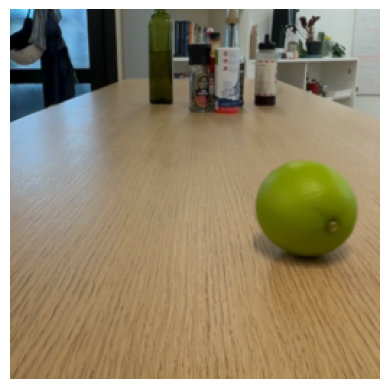

In [13]:
from torchvision import transforms
from torchvision.transforms._transforms_video import NormalizeVideo
from matplotlib import pyplot as plt
from PIL import Image

MEAN = [0.5, 0.5, 0.5]
STD = [0.5, 0.5, 0.5]
SIZE = 256

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(SIZE),
    transforms.CenterCrop(SIZE),
    transforms.Lambda(lambda x: x.unsqueeze(1)),  # [C,1,H,W]
    NormalizeVideo(mean=MEAN, std=STD),
])

image = Image.open("data/frame_edits/edit_v3.png")

cond_frame = transform(image)  # [C, 1, H, W], normalized

plt.imshow(image)
plt.axis('off');

In [14]:
num_keep_tokens_list = [2**i for i in range(9)] # 1, 2, 4, 8, ..., 256

with get_bf16_context(enable_bf16):
    reconstructed_videos = model.detokenize(
        [token_ids[0] for _ in range(len(num_keep_tokens_list))],
        num_keep_tokens_list=num_keep_tokens_list,
        **decoder_generation_kwargs,
        conditioning_frames=[cond_frame[None].to(device) for _ in range(len(num_keep_tokens_list))]
    ) # List of videos of shape (1, C, T, H, W) in [-1, 1]
    reconstructed_videos = [r.cpu().float() for r in reconstructed_videos]  # Move to CPU for visualization

/root/ml-videoflextok/videoflextok/model/utils/posembs.py:133: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  posembs = posembs[slices]


In [15]:
show_videos_row_video(reconstructed_videos, bottom_pad_px=128, fps=8)